# Estimation covariance: parameter uncertainty from a single solve

Fitting a model to data answers one question and immediately raises a
second: how certain are the fitted parameters? This notebook shows that
the solver which just found the least-squares fit is already holding the
answer. The covariance of the estimates is the estimated noise variance
times the inverse of the reduced Hessian of the Lagrangian, and that
matrix sits inside the KKT factorization the solve produced. Declare
which variables are the fitted parameters and which hold the residuals,
solve once, and `covariance()` reads it off: one backsolve per
parameter, no second optimization, no finite differencing.

The model is a two-parameter decay, $y = A\,e^{-kx}$, fit to synthetic
noisy data. A Monte Carlo of refitted datasets then shows what the
resulting confidence ellipse does and does not capture. Built with
[pyomo-pounce](https://pypi.org/project/pyomo-pounce/); the same
material runs interactively at
[estimation-covariance.griffith-pse.com](https://estimation-covariance.griffith-pse.com).


## The estimation problem

$$
\begin{aligned}
\min_{A,\;k}\quad & \sum_{i=1}^{n} r_i^{2} \\
\text{s.t.}\quad  & r_i = y_i - A\,e^{-k x_i}, \qquad i = 1,\dots,n
\end{aligned}
$$

The residuals are explicit variables rather than an expression folded
into the objective. That is what gives `covariance()` a container to
read: the residual count and the sum of squares both come from it, so
the degrees of freedom and the noise variance estimate
$\hat\sigma^{2} = \sum_i r_i^2 / (n - p)$ are derived rather than
supplied.

The warm start comes from a log-linear regression on the positive
samples ($\log y = \log A - kx$). A fixed starting point strands the
solver on low-information windows; this one uses only the data.


In [1]:
import numpy as np
import pyomo.environ as pyo

import pyomo_pounce  # registers 'pounce' with SolverFactory
from pyomo_pounce import covariance, declare_fitted, declare_residual

A_TRUE, K_TRUE, SIGMA = 2.0, 1.3, 0.05
rng = np.random.default_rng(7)
x = np.linspace(0.0, 3.0, 20)
y = A_TRUE * np.exp(-K_TRUE * x) + SIGMA * rng.standard_normal(x.size)


def initial_guess(x, y):
    pos = y > 0
    slope, intercept = np.polyfit(x[pos], np.log(y[pos]), 1)
    return float(np.exp(intercept)), float(-slope)


def build(x, y, declare=True):
    a0, k0 = initial_guess(x, y)
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, x.size - 1)
    m.A = pyo.Var(initialize=a0)
    m.k = pyo.Var(initialize=k0)
    m.r = pyo.Var(m.I, initialize=0.0)

    @m.Constraint(m.I)
    def res(m, i):
        return m.r[i] == float(y[i]) - m.A * pyo.exp(-m.k * float(x[i]))

    m.obj = pyo.Objective(expr=sum(m.r[i] ** 2 for i in m.I))
    if declare:
        declare_fitted(m.A, m.k)
        declare_residual(m.r)
    return m


m = build(x, y)
pyo.SolverFactory("pounce").solve(m)   # one ordinary solve
cov = covariance(m)                    # zero further arguments

A_hat, k_hat = pyo.value(m.A), pyo.value(m.k)
C = np.array(cov.matrix)
print(f"A = {A_hat:.4f} +/- {cov.std_err[m.A]:.4f}   (true {A_TRUE})")
print(f"k = {k_hat:.4f} +/- {cov.std_err[m.k]:.4f}   (true {K_TRUE})")
print(f"sigma_hat = {np.sqrt(cov.sigma_sq):.4f}        (true {SIGMA})")
print(f"correlation(A, k) = {cov.correlation[m.A, m.k]:+.3f}")


A = 2.0039 +/- 0.0316   (true 2.0)
k = 1.3309 +/- 0.0329   (true 1.3)
sigma_hat = 0.0420        (true 0.05)
correlation(A, k) = +0.629


## From the matrix to the ellipse

The 95% joint confidence region is the level set
$(\theta-\hat\theta)^{\mathsf T} C^{-1} (\theta-\hat\theta)
\le \chi^{2}_{2,\,0.95} = 5.991$, centered on the estimate exactly
as a practitioner would draw it. Its principal axes run along the
eigenvectors of $C$ with half-lengths $\sqrt{5.991\,\lambda_i}$.
The positive correlation tilts the region: raising $A$ lifts the
curve and raising $k$ pulls it back down, so pairs that move together
fit the data almost equally well, and errors in the two estimates move
together. Zeroing the off-diagonal gives the dotted companion ellipse
with the same reach along each axis and no tilt.


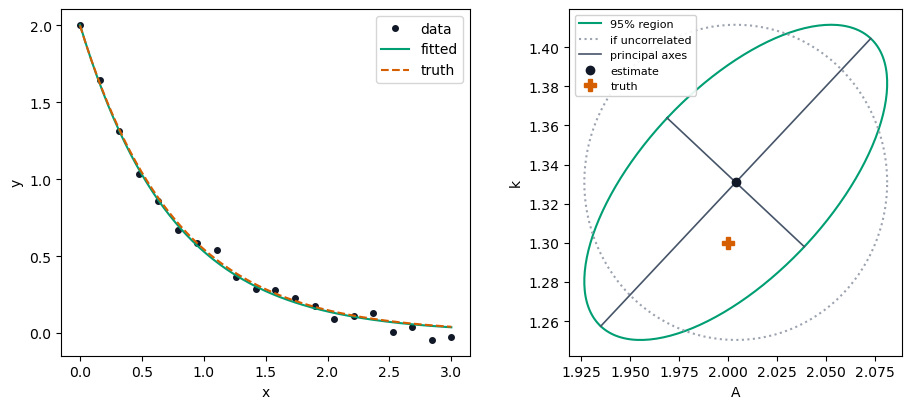

In [2]:
import matplotlib.pyplot as plt

GREEN, ORANGE, SLATE, GRAY = "#009E73", "#D55E00", "#475569", "#9ca3af"
CHI2 = 5.991  # 95th percentile of chi-square with 2 degrees of freedom


def ellipse(center, C, n=241):
    evals, evecs = np.linalg.eigh(C)
    th = np.linspace(0.0, 2.0 * np.pi, n)
    unit = np.stack([np.cos(th), np.sin(th)])
    return center[:, None] + evecs @ (np.sqrt(CHI2 * evals)[:, None] * unit)


center = np.array([A_hat, k_hat])
E = ellipse(center, C)
E0 = ellipse(center, np.diag(np.diag(C)))

fig, (axd, axp) = plt.subplots(1, 2, figsize=(9.6, 4.2))

xx = np.linspace(0.0, 3.0, 200)
axd.plot(x, y, "o", ms=4, color="#111827", label="data")
axd.plot(xx, A_hat * np.exp(-k_hat * xx), color=GREEN, label="fitted")
axd.plot(xx, A_TRUE * np.exp(-K_TRUE * xx), "--", color=ORANGE, label="truth")
axd.set_xlabel("x"); axd.set_ylabel("y"); axd.legend()

axp.plot(E[0], E[1], color=GREEN, label="95% region")
axp.plot(E0[0], E0[1], ":", color=GRAY, label="if uncorrelated")
evals, evecs = np.linalg.eigh(C)
for i in range(2):
    tip = evecs[:, i] * np.sqrt(CHI2 * evals[i])
    axp.plot([center[0] - tip[0], center[0] + tip[0]],
             [center[1] - tip[1], center[1] + tip[1]], color=SLATE, lw=1.2,
             label="principal axes" if i == 0 else None)
axp.plot(*center, "o", color="#111827", label="estimate")
axp.plot(A_TRUE, K_TRUE, "P", ms=9, color=ORANGE, label="truth")
axp.set_aspect("equal")  # equal scaling keeps the axes truly orthogonal
axp.set_xlabel("A"); axp.set_ylabel("k"); axp.legend(fontsize=8, loc="upper left", framealpha=0.9)
plt.tight_layout()
plt.show()


## The replication check

The sweep asks a replication question: rerun the experiment, refit,
and see where the new estimate lands relative to the region above.
Each draw generates an independent dataset from the same truth and
noise and refits it, one full solve per draw.

Two counts tell the story. The estimate-centered region captures a
replication about 78% of the time on average, not 95%, because the
center is itself an estimate carrying its own error: a replication
differs from it with twice the covariance. The 95% belongs to a
different event, the region containing the **true** parameters, which
holds for 95% of datasets. Counting the same cloud against the region
translated to the truth shows that second number.


refits inside the drawn, estimate-centered region: 78.0%
refits inside the same region taken about the truth: 86.0%


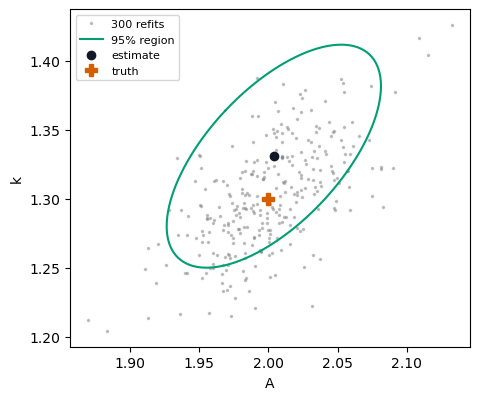

In [3]:
opt = pyo.SolverFactory("pounce")
fits = []
for s in range(300):
    r = np.random.default_rng(1_000_003 + s)
    ys = A_TRUE * np.exp(-K_TRUE * x) + SIGMA * r.standard_normal(x.size)
    ms = build(x, ys, declare=False)   # plain solves for the refits
    opt.solve(ms)
    fits.append((pyo.value(ms.A), pyo.value(ms.k)))
fits = np.array(fits)

Cinv = np.linalg.inv(C)
d = fits - center
capture = (np.einsum("ij,jk,ik->i", d, Cinv, d) <= CHI2).mean()
dt = fits - np.array([A_TRUE, K_TRUE])
about_truth = (np.einsum("ij,jk,ik->i", dt, Cinv, dt) <= CHI2).mean()
print(f"refits inside the drawn, estimate-centered region: {100 * capture:.1f}%")
print(f"refits inside the same region taken about the truth: {100 * about_truth:.1f}%")

fig, ax = plt.subplots(figsize=(4.9, 4.5))
ax.plot(fits[:, 0], fits[:, 1], ".", ms=3, alpha=0.4, color="#7f7f7f",
        label="300 refits")
ax.plot(E[0], E[1], color=GREEN, label="95% region")
ax.plot(*center, "o", color="#111827", label="estimate")
ax.plot(A_TRUE, K_TRUE, "P", ms=9, color=ORANGE, label="truth")
ax.set_aspect("equal")
ax.set_xlabel("A"); ax.set_ylabel("k"); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## What unidentifiability looks like

Same model, but the data cover only a late window, $x \in [2.5, 3]$.
There the fit pins the local value and slope while $A$ is a long
extrapolation back to $x = 0$: only a combination of $A$ and $k$ is
determined. The covariance reports it before any prediction is made:
correlation near $+1$ and standard errors orders of magnitude beyond
the full-window fit.


In [4]:
x_late = np.linspace(2.5, 3.0, 20)
y_late = A_TRUE * np.exp(-K_TRUE * x_late) + 0.01 * np.random.default_rng(11).standard_normal(20)

ml = build(x_late, y_late)
pyo.SolverFactory("pounce").solve(ml)
cov_l = covariance(ml)

print(f"A = {pyo.value(ml.A):.3f} +/- {cov_l.std_err[ml.A]:.3f}   (full window: +/- {cov.std_err[m.A]:.4f})")
print(f"k = {pyo.value(ml.k):.3f} +/- {cov_l.std_err[ml.k]:.3f}   (full window: +/- {cov.std_err[m.k]:.4f})")
print(f"correlation(A, k) = {cov_l.correlation[ml.A, ml.k]:+.5f}")


A = 2.227 +/- 1.270   (full window: +/- 0.0316)
k = 1.327 +/- 0.212   (full window: +/- 0.0329)
correlation(A, k) = +0.99859


## References

- J. Kitchin, POUNCE: [github.com/jkitchin/pounce](https://github.com/jkitchin/pounce);
  the Pyomo plugin and `covariance()` ship as
  [pyomo-pounce](https://pypi.org/project/pyomo-pounce/).
- G. A. F. Seber and C. J. Wild, *Nonlinear Regression*. Wiley, 1989.
  The asymptotic covariance of least-squares estimates.
- G. Cumming and R. Maillardet, "Confidence intervals and
  replication: Where will the next mean fall?" *Psychological
  Methods*, 11(3):217-227, 2006. The capture-percentage result: a
  95% confidence interval captures a replication's estimate well
  under 95% of the time.
